# 03 — Concisão

A **concisão** é a segunda dimensão mais importante do estudo. Resposta a edital concursário tem um critério prático muito específico: o usuário quer **a resposta**, não um ensaio sobre o tópico. Texto que não acrescenta informação é ruído — pior, é tempo de leitura desperdiçado por quem está estudando para uma prova.

**Como ela é medida.** Cada resposta foi marcada com um indicador binário (`concisao_score` ∈ {0, 1}) que vale 1 quando a resposta vai direto ao ponto, sem preâmbulo do tipo "Conforme o edital..." nem fechamento do tipo "Em síntese...". A medida agregada por modelo é a **taxa de concisão**: a fração das 150 respostas marcadas como diretas.

**Por que esse notebook se apoia também em tokens.** A taxa de concisão é binária e perde nuances. Por isso, junto com ela, olhamos **tokens da resposta** (`resposta_tokens_tiktoken`) — o tamanho do texto efetivamente entregue ao usuário, contado pela tokenização do tiktoken. Como o estudo confirmou, **as duas medidas se correlacionam fortemente**: modelos cujo `concisao_score` é alto têm textos curtos. Por isso, parte da análise usa só os tokens — a métrica contínua é mais fácil de visualizar.

> **Nota técnica.** Tokens de "saída" (`output_tokens`) somam o que o modelo gerou no fluxo interno — raciocínio, chamadas de ferramenta e a resposta. Para *concisão*, o que interessa é o texto que o usuário lê, então usamos sempre `resposta_tokens_tiktoken`. O fluxo interno entra apenas no notebook 05 (custo).


In [2]:
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from utils import (carregar_dados, agrega_por_modelo, estilo_padrao,
                   CORES_PROVEDOR, ORDEM_MODELOS, PARES_CHAT_API,
                   MARKER_API, MARKER_CHAT, titulo_acima, anota_sem_sobrepor,
                   legenda_provedor_origem, bootstrap_ic)

estilo_padrao()
df = carregar_dados()
mestre = agrega_por_modelo(df)

## 1. A correlação que sustenta o uso de tokens

Antes de tudo, mostramos por que tokens da resposta é uma proxy aceitável (e mais informativa) de concisão. Cada ponto é um **modelo**, não uma linha individual: a correlação ao nível de modelo é o que importa para visualizações comparativas.


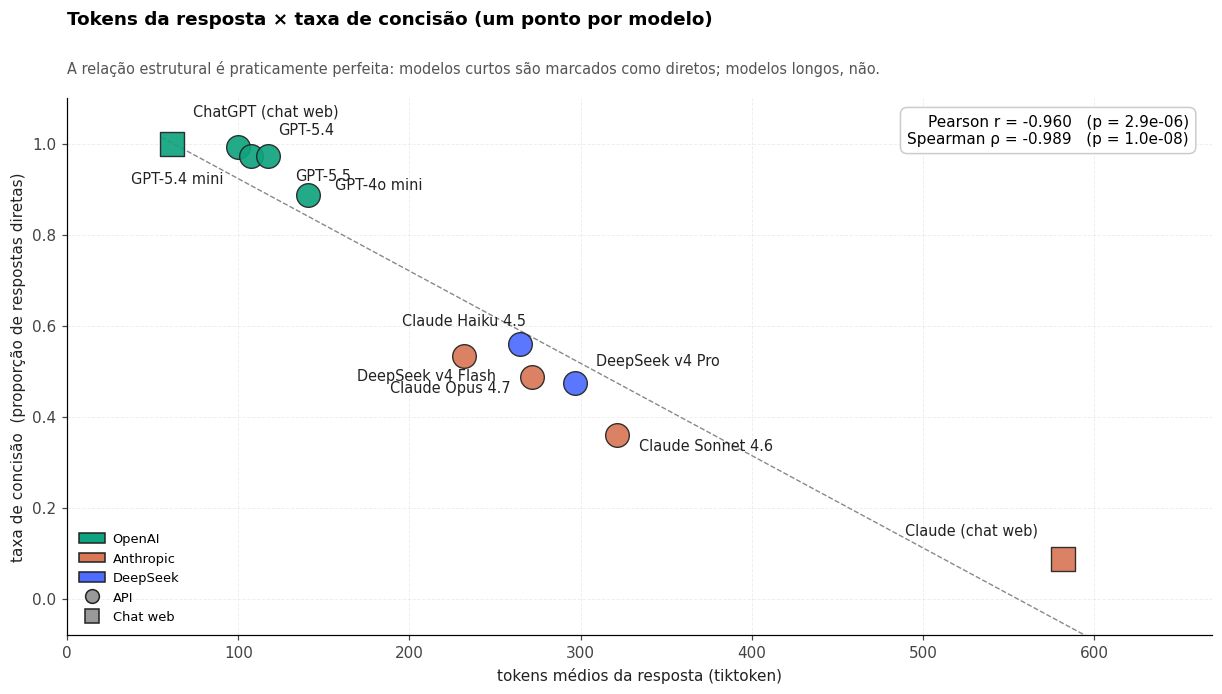

In [3]:
x = mestre['tokens_resp']
y = mestre['concisao']

r_p, p_p = stats.pearsonr(x, y)
r_s, p_s = stats.spearmanr(x, y)

fig, ax = plt.subplots(figsize=(11, 6.2), layout='constrained')

# Plota cada modelo com sua cor/marcador
for nome, row in mestre.iterrows():
    ax.scatter(row['tokens_resp'], row['concisao'],
               s=240, color=row['cor'], marker=row['marker'],
               edgecolor='#222', linewidth=0.9, zorder=3, alpha=0.92)

# Linha de tendência (regressão linear simples, só para guiar o olho)
sl, ic_, *_ = stats.linregress(x, y)
xx = np.linspace(x.min() * 0.9, x.max() * 1.05, 100)
ax.plot(xx, sl * xx + ic_, color='#888', lw=0.9, ls='--', zorder=1,
        label=f'tendência linear')

# Rótulos (editáveis)
anota_sem_sobrepor(ax, x.values, y.values, mestre.index.tolist(),
    fontsize=9.5,
    offsets_manuais={
        'GPT-4o mini':        ( 18,   2),
        'GPT-5.4 mini':       (-10, -16),   # esquerda-baixo
        'GPT-5.4':            ( 18,  12),
        'GPT-5.5':            ( 18,  -8),
        'ChatGPT (chat web)': ( 14,  16),
        'Claude Haiku 4.5':   (  0,  18),   # acima do ponto
        'Claude Sonnet 4.6':  ( 14,  -2),
        'Claude Opus 4.7':    (-14,  -2),
        'Claude (chat web)':  (-16,  14),
        'DeepSeek v4 Flash':  (-16, -16),   # canto inferior esquerdo
        'DeepSeek v4 Pro':    ( 14,  10),
    })

ax.set_xlim(0, x.max() * 1.15)
ax.set_ylim(-0.08, 1.10)
ax.set_xlabel('tokens médios da resposta (tiktoken)')
ax.set_ylabel('taxa de concisão  (proporção de respostas diretas)')

ax.text(0.98, 0.97,
        f'Pearson r = {r_p:.3f}   (p = {p_p:.1e})\n'
        f'Spearman ρ = {r_s:.3f}   (p = {p_s:.1e})',
        transform=ax.transAxes, va='top', ha='right',
        fontsize=10,
        bbox=dict(boxstyle='round,pad=0.45', facecolor='white', edgecolor='#ccc'))

legenda_provedor_origem(ax, loc='lower left')

titulo_acima(ax,
    'Tokens da resposta × taxa de concisão (um ponto por modelo)',
    'A relação estrutural é praticamente perfeita: modelos curtos são marcados como diretos; modelos longos, não.')

plt.show()

**A correlação é forte e negativa**: quanto mais tokens a resposta tem, menor a chance de ela ter sido classificada como concisa. Isso valida o uso de **tokens da resposta** como variável contínua de concisão no resto do notebook — visualizações com 11 modelos ficam mais legíveis com um eixo numérico do que com uma proporção em [0, 1].

> Como cada ponto é um modelo (agregado de 150 respostas), a correlação fica robusta a ruído individual. Ao nível de linha, a relação ainda existe mas é mais difusa — uma única resposta curta pode ser não-concisa (por causa de um preâmbulo bem rápido) e vice-versa.


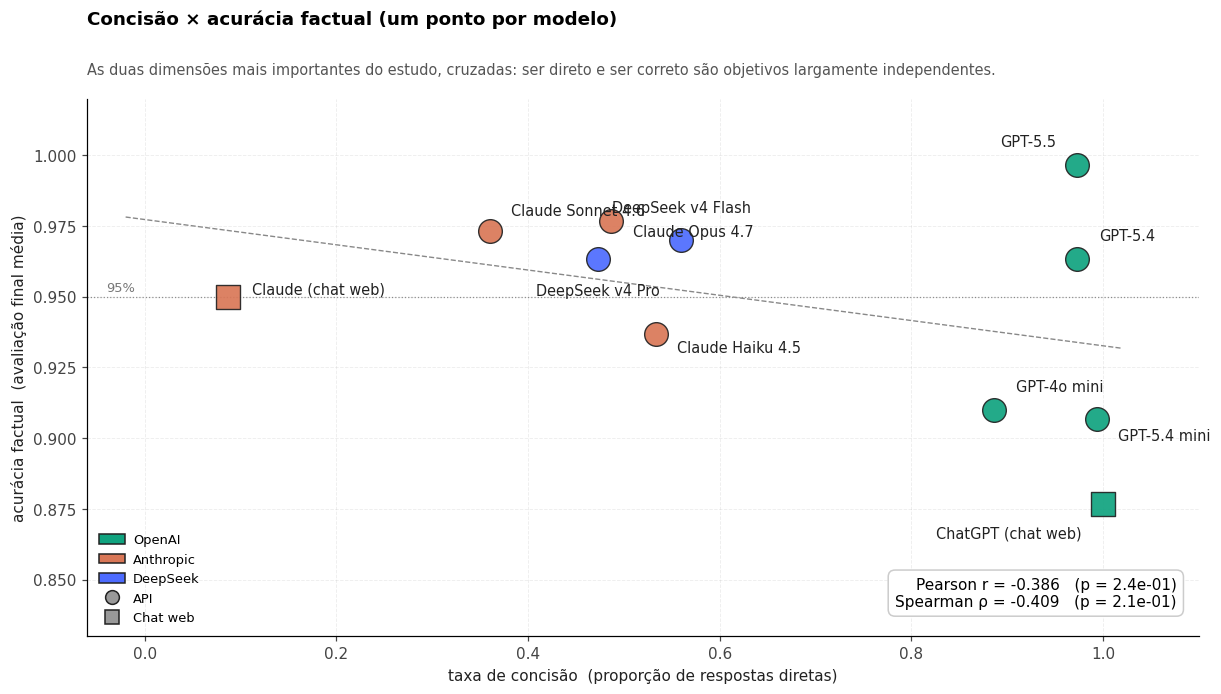

In [4]:
## 1b. Concisão × acurácia factual — as duas dimensões juntas

x = mestre['concisao']
y = mestre['precisao']

r_p, p_p = stats.pearsonr(x, y)
r_s, p_s = stats.spearmanr(x, y)

fig, ax = plt.subplots(figsize=(11, 6.2), layout='constrained')

# Cada modelo com sua cor (provedor) e marcador (canal)
for nome, row in mestre.iterrows():
    ax.scatter(row['concisao'], row['precisao'],
               s=240, color=row['cor'], marker=row['marker'],
               edgecolor='#222', linewidth=0.9, zorder=3, alpha=0.92)

# Linha de tendência (só para guiar o olho)
sl, ic_, *_ = stats.linregress(x, y)
xx = np.linspace(-0.02, 1.02, 100)
ax.plot(xx, sl * xx + ic_, color='#888', lw=0.9, ls='--', zorder=1,
        label='tendência linear')

# Rótulos (editáveis — mova o offset do modelo que estiver disputando espaço)
anota_sem_sobrepor(ax, x.values, y.values, mestre.index.tolist(),
    fontsize=9.5,
    offsets_manuais={
        'GPT-4o mini':        ( 14,  10),
        'GPT-5.4 mini':       ( 14,  -6),
        'GPT-5.4':            ( 14,  10),
        'GPT-5.5':            (-14,  10),
        'ChatGPT (chat web)': (-14, -14),   # concisão = 1,0, encostado na borda direita
        'Claude Haiku 4.5':   ( 14,  -4),
        'Claude Sonnet 4.6':  ( 14,   8),
        'Claude Opus 4.7':    ( 14,  -2),
        'Claude (chat web)':  ( 16,   0),   # concisão ~0,09, perto da borda esquerda
        'DeepSeek v4 Flash':  (  0,  16),
        'DeepSeek v4 Pro':    (  0, -16),
    })

ax.set_xlim(-0.06, 1.10)
ax.set_ylim(0.83, 1.02)
ax.set_xlabel('taxa de concisão  (proporção de respostas diretas)')
ax.set_ylabel('acurácia factual  (avaliação final média)')

# Patamar de referência de 95%, como no notebook 02
ax.axhline(0.95, ls=':', color='#888', lw=0.8, zorder=1)
ax.text(-0.04, 0.951, '95%', fontsize=8.5, color='#777', va='bottom', ha='left')

ax.text(0.98, 0.05,
        f'Pearson r = {r_p:.3f}   (p = {p_p:.1e})\n'
        f'Spearman ρ = {r_s:.3f}   (p = {p_s:.1e})',
        transform=ax.transAxes, va='bottom', ha='right',
        fontsize=10,
        bbox=dict(boxstyle='round,pad=0.45', facecolor='white', edgecolor='#ccc'))

legenda_provedor_origem(ax, loc='lower left')

titulo_acima(ax,
    'Concisão × acurácia factual (um ponto por modelo)',
    'As duas dimensões mais importantes do estudo, cruzadas: ser direto e ser correto são objetivos largamente independentes.')

plt.show()

## 2. Ranking de concisão (por tokens da resposta)

Aqui usamos a medida contínua. Barra mais curta = resposta mais sucinta. A ordem visual segue a convenção do estudo (OpenAI, Anthropic, DeepSeek), com o chat web encaixado em cada provedor.


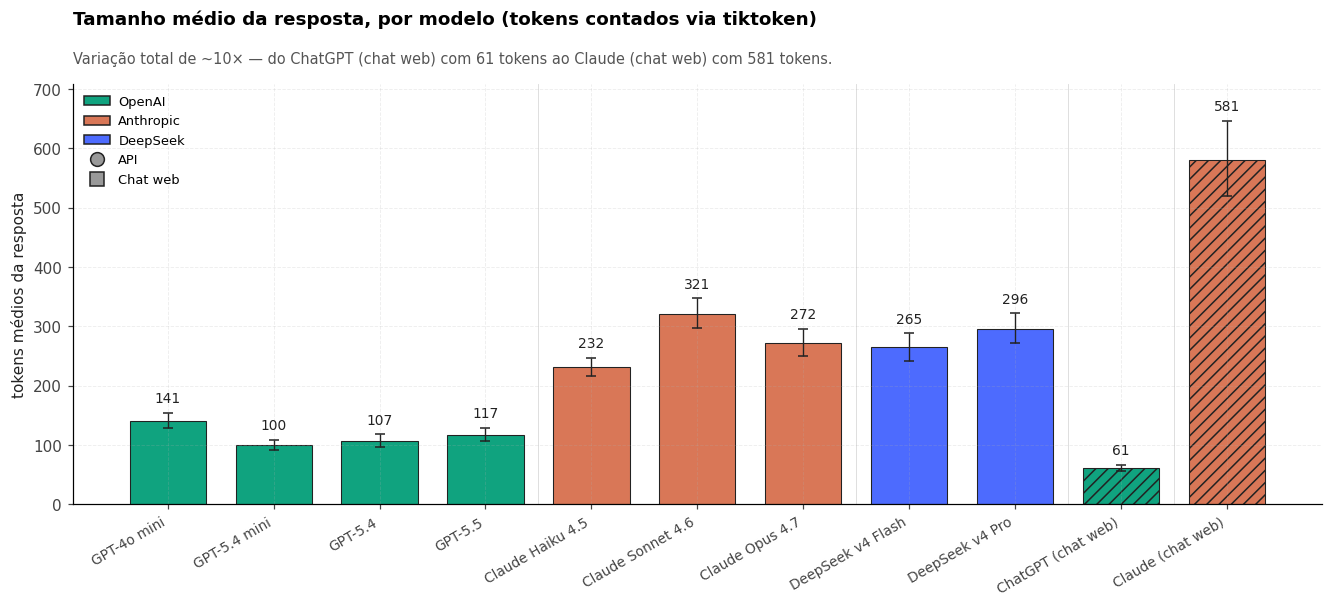

In [3]:
fig, ax = plt.subplots(figsize=(12, 5.4), layout='constrained')

xs = np.arange(len(ORDEM_MODELOS))
valores = mestre['tokens_resp'].values
cores = mestre['cor'].values
canais = mestre['origem'].values

bars = ax.bar(xs, valores, color=cores, edgecolor='#222',
              linewidth=0.7, width=0.72)
for b, c in zip(bars, canais):
    if c == 'Chat web':
        b.set_hatch('///')

# IC bootstrap nas alturas
for i, m in enumerate(ORDEM_MODELOS):
    s = df.loc[df['modelo_display'] == m, 'resposta_tokens_tiktoken']
    lo, hi = bootstrap_ic(s, n_boot=2000)
    ax.errorbar(i, s.mean(), yerr=[[s.mean()-lo],[hi-s.mean()]],
                fmt='none', ecolor='#222', elinewidth=0.9, capsize=3, zorder=4)

# Rótulos no topo
for x, v, m in zip(xs, valores, ORDEM_MODELOS):
    s = df.loc[df['modelo_display'] == m, 'resposta_tokens_tiktoken']
    _, hi = bootstrap_ic(s, n_boot=500)
    ax.text(x, hi + 12, f'{v:.0f}', ha='center', va='bottom',
            fontsize=9, color='#222')

# Separadores de provedor
last = None
for i, p in enumerate(mestre['provedor'].values):
    if last is not None and p != last:
        ax.axvline(i - 0.5, color='#ddd', lw=0.6, zorder=0)
    last = p

ax.set_xticks(xs)
ax.set_xticklabels(ORDEM_MODELOS, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('tokens médios da resposta')
ax.set_ylim(0, mestre['tokens_resp'].max() * 1.22)

legenda_provedor_origem(ax, loc='upper left')

titulo_acima(ax,
    'Tamanho médio da resposta, por modelo (tokens contados via tiktoken)',
    'Variação total de ~10× — do ChatGPT (chat web) com 61 tokens ao Claude (chat web) com 581 tokens.')

plt.show()

**O contraste é gritante.** Em um extremo, **ChatGPT (chat web)** com **61 tokens** de média — respostas tipicamente de uma frase. No outro, **Claude (chat web)** com **581 tokens** — quase 10× mais texto. Os dois chats web ocupam as posições extremas.

**Padrão por família.**

- OpenAI escreve curto via API (100–140 tokens), e *muito curto* via chat web.
- Anthropic escreve longo via API (230–320 tokens), e *muito longo* via chat web. O Claude no navegador parece ter sido tunado para ser explicativo — o oposto da decisão da OpenAI.
- DeepSeek fica em um meio-termo (265–296 tokens), mais perto do estilo Anthropic do que do OpenAI.


## 3. Pareadas: Chat web vs API do mesmo provedor

A mesma comparação Chat-vs-API que fizemos para acurácia factual, agora aplicada à concisão. O resultado é o oposto do que a intuição sugere: os chats web não são meros derivados dos modelos via API, são produtos com **estilos editorialmente distintos**.


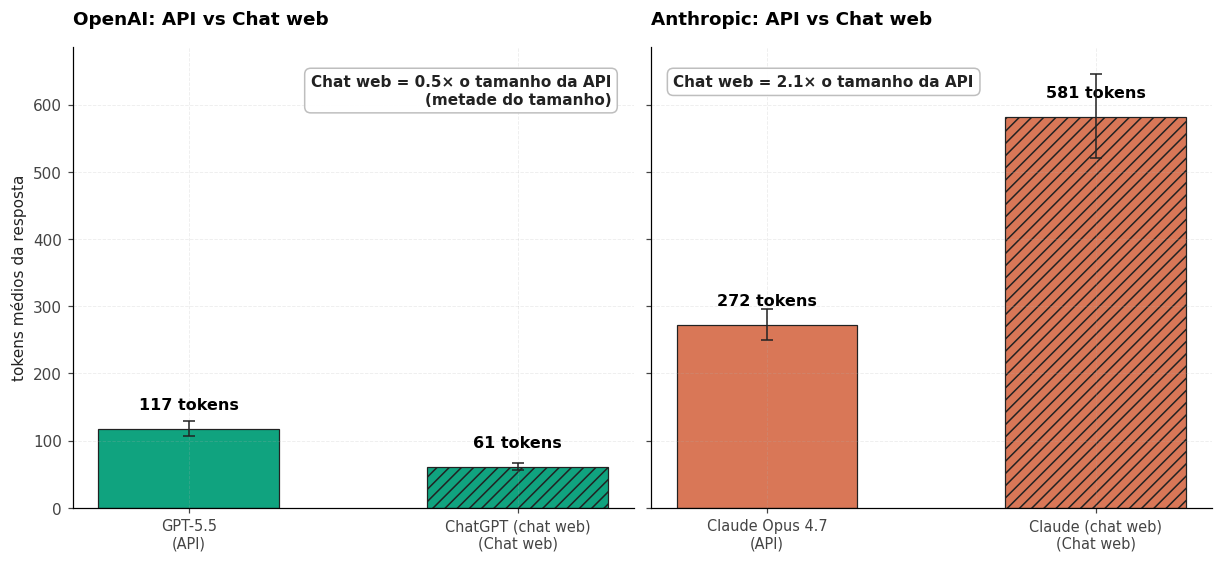

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.0), sharey=True, layout='constrained')

for ax, (chat, api) in zip(axes, PARES_CHAT_API):
    sub = mestre.loc[[chat, api]]
    provedor = sub['provedor'].iloc[0]
    cor_base = CORES_PROVEDOR[provedor]

    rotulos = [api, chat]
    valores = [sub.loc[api, 'tokens_resp'], sub.loc[chat, 'tokens_resp']]
    xs = np.arange(2)

    bars = ax.bar(xs, valores, color=cor_base, edgecolor='#222',
                  linewidth=0.8, width=0.55)
    bars[1].set_hatch('///')

    # IC
    for i, m in enumerate(rotulos):
        s = df.loc[df['modelo_display'] == m, 'resposta_tokens_tiktoken']
        lo, hi = bootstrap_ic(s, n_boot=2000)
        ax.errorbar(xs[i], s.mean(),
                    yerr=[[s.mean()-lo],[hi-s.mean()]],
                    fmt='none', ecolor='#222', elinewidth=1.0, capsize=4, zorder=4)

    for i, v in enumerate(valores):
        ax.text(i, v + 25, f'{v:.0f} tokens',
                ha='center', va='bottom', fontsize=10.5, fontweight='bold')

    # Razão API↔Chat — anotada como caixa no canto, longe das barras
    razao = valores[1] / valores[0] if valores[0] else float('nan')
    if razao >= 1:
        msg = f'Chat web = {razao:.1f}× o tamanho da API'
    else:
        msg = f'Chat web = {razao:.1f}× o tamanho da API\n(metade do tamanho)'

    # Quando a barra do chat (direita) é maior, caixa vai pra esquerda;
    # quando é menor, caixa vai pra direita.
    if valores[1] > valores[0]:
        x_caixa, ha_caixa = 0.04, 'left'
    else:
        x_caixa, ha_caixa = 0.96, 'right'
    ax.text(x_caixa, 0.94, msg,
            transform=ax.transAxes, ha=ha_caixa, va='top',
            fontsize=10, color='#222', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor='#bbb', alpha=0.95))

    ax.set_xticks(xs)
    ax.set_xticklabels([f'{rotulos[0]}\n(API)', f'{rotulos[1]}\n(Chat web)'],
                       fontsize=9.5)

    titulo_acima(ax, f'{provedor}: API vs Chat web', None)

axes[0].set_ylim(0, max(mestre['tokens_resp']) * 1.18)
axes[0].set_ylabel('tokens médios da resposta')

plt.show()

**Duas direções opostas.**

- **OpenAI**: o chat web é **metade** do tamanho do GPT-5.5 via API (0,5×). Resposta de uma frase, sem floreio, frequentemente sem pontuação final formal. É o estilo "Wikipedia oneliner".
- **Anthropic**: o chat web é **mais do que o dobro** do Claude Opus 4.7 via API (2,1×). Resposta que toma uma página, com contexto, justificativa e às vezes alternativas. É o estilo "consultoria".

Cada provedor decidiu polos diferentes para o produto comercial. O TCC mostra esse contraste pela primeira vez de forma direta — em ambos os casos, o canal API entrega algo *intermediário* entre os dois extremos do chat web.


## 4. Distribuição da concisão (variabilidade dentro de cada modelo)

A barra acima é só a média. Vale ver também a **distribuição** — alguns modelos respondem sempre no mesmo tamanho, outros oscilam muito. Esse gráfico usa boxplot para preservar a variação.


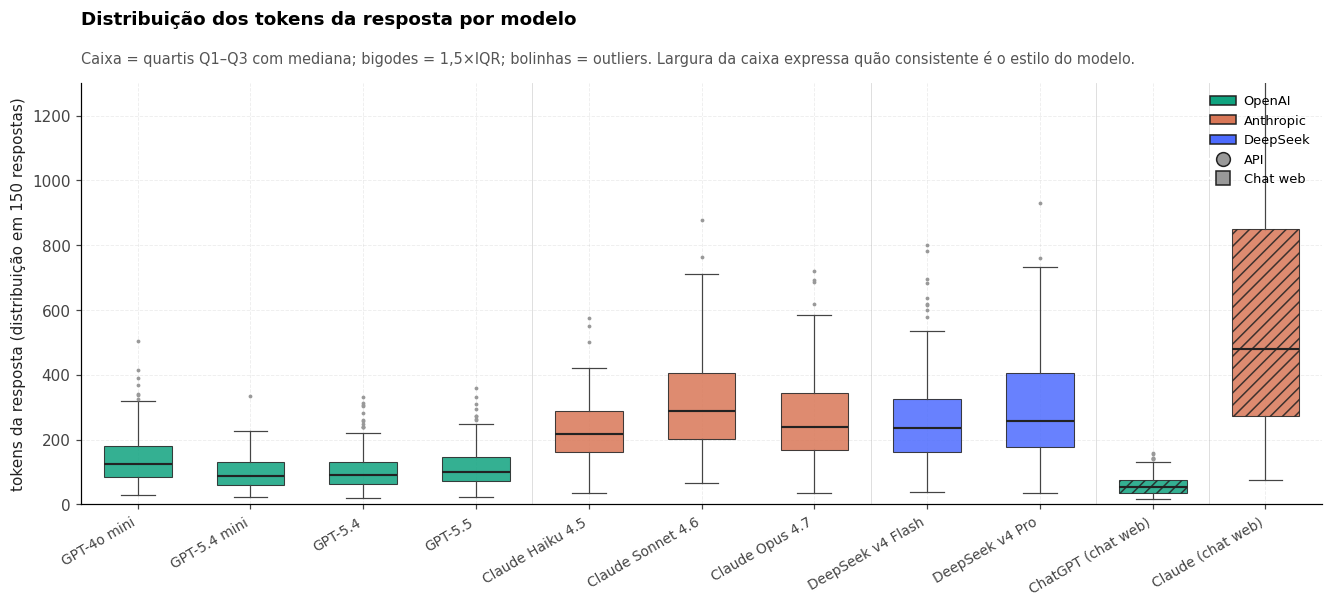

In [5]:
fig, ax = plt.subplots(figsize=(12, 5.4), layout='constrained')

# Boxplot por modelo, na ordem padrão
dados = [df.loc[df['modelo_display'] == m, 'resposta_tokens_tiktoken'].values
         for m in ORDEM_MODELOS]

bp = ax.boxplot(dados, positions=np.arange(len(ORDEM_MODELOS)),
                widths=0.6, patch_artist=True,
                medianprops=dict(color='#222', lw=1.4),
                flierprops=dict(marker='o', markersize=2.5,
                                markerfacecolor='#999', markeredgecolor='none'),
                whiskerprops=dict(color='#444', lw=0.8),
                capprops=dict(color='#444', lw=0.8))

# Colorir conforme provedor; hatch para chat web
for patch, cor, canal in zip(bp['boxes'], mestre['cor'].values, mestre['origem'].values):
    patch.set_facecolor(cor)
    patch.set_edgecolor('#222')
    patch.set_linewidth(0.7)
    patch.set_alpha(0.85)
    if canal == 'Chat web':
        patch.set_hatch('///')

# Separadores de provedor
last = None
for i, p in enumerate(mestre['provedor'].values):
    if last is not None and p != last:
        ax.axvline(i - 0.5, color='#ddd', lw=0.6, zorder=0)
    last = p

ax.set_xticks(np.arange(len(ORDEM_MODELOS)))
ax.set_xticklabels(ORDEM_MODELOS, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('tokens da resposta (distribuição em 150 respostas)')
ax.set_ylim(0, 1300)

legenda_provedor_origem(ax, loc='upper right')

titulo_acima(ax,
    'Distribuição dos tokens da resposta por modelo',
    'Caixa = quartis Q1–Q3 com mediana; bigodes = 1,5×IQR; bolinhas = outliers. '
    'Largura da caixa expressa quão consistente é o estilo do modelo.')

plt.show()

**Padrões na variabilidade.**

- **GPT-5.4 mini, GPT-5.5 e ChatGPT (chat web)** têm caixas muito apertadas: respondem sempre no mesmo tamanho. Há um "template" interno consistente.
- **Claude (chat web) e Claude Sonnet 4.6** têm caixas largas, com outliers passando de 1000 tokens. Respostas oscilam bastante — algumas curtas, outras com muita explicação adicional.
- **Modelos Anthropic e DeepSeek concentram outliers para cima**: quando saem do padrão, é para *escrever mais*, nunca menos. Os modelos OpenAI fazem o oposto.

Esse padrão de variabilidade reaparece no notebook 05 (custo): respostas mais longas custam mais e demoram mais.

---

A acurácia factual posicionou os modelos verticalmente; a concisão posicionou-os horizontalmente. **Latência (04)** e **custo (05)** vão preencher os outros dois eixos do estudo, restritos ao canal API.
